# Tahap 2 — Case Representation
## CBR Sistem Analisis Putusan Narkotika

**Tujuan:** Representasikan setiap putusan dalam struktur data terorganisir.

**Langkah:**
1. Ekstraksi metadata (no_perkara, tanggal, jenis perkara, pasal, pihak)
2. Ekstraksi konten kunci (ringkasan fakta, argumen hukum)
3. Feature engineering (word count, bag-of-words)
4. Simpan ke `/data/processed/cases.csv` dan `cases.json`

## 2.0 Setup

In [1]:
import os, re, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
os.chdir(ROOT)
print(f'Working directory: {ROOT}')

RAW_DIR  = 'data/raw'
PROC_DIR = 'data/processed'
os.makedirs(PROC_DIR, exist_ok=True)

Working directory: e:\ragil\semester 6\Penalaran Komputer\cbr_narkotika\cbr_narkotika


## 2.1 Pola Ekstrasi Metadata (Regex)

In [2]:
# Pola regex untuk ekstraksi metadata dari teks putusan
P_NO_PERKARA = re.compile(r'Nomor\s+([\d/\w.]+)', re.IGNORECASE)
P_TANGGAL    = re.compile(
    r'(\d{1,2}\s+(?:Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|'
    r'September|Oktober|November|Desember)\s+\d{4})', re.IGNORECASE)
P_TERDAKWA   = re.compile(r'Nama Lengkap\s*:\s*(.+)', re.IGNORECASE)
P_PASAL      = re.compile(
    r'Pasal\s+(\d+\s+ayat\s*\(\d+\)\s+UU[^\.]+Narkotika)', re.IGNORECASE)
P_JENIS_NARK = re.compile(
    r'(sabu-sabu|heroin|ganja|ekstasi|kokain|metamfetamina|cannabis|mdma|cocaine)',
    re.IGNORECASE)
P_BERAT      = re.compile(
    r'(\d+(?:[.,]\d+)?\s*(?:gram|kilogram|kg|gr|paket\s*kecil|paket))',
    re.IGNORECASE)
P_AMAR       = re.compile(
    r'(?:Menjatuhkan pidana|pidana penjara|pidana mati|penjara seumur hidup)'
    r'[^\.]{5,120}', re.IGNORECASE)
P_DAKWAAN    = re.compile(
    r'DAKWAAN:(.+?)(?=FAKTA|ANALISIS|MENGADILI)', re.IGNORECASE | re.DOTALL)
P_FAKTA      = re.compile(
    r'FAKTA-FAKTA HUKUM:(.+?)(?=ANALISIS|MENGADILI)', re.IGNORECASE | re.DOTALL)
P_ANALISIS   = re.compile(
    r'ANALISIS HUKUM:(.+?)(?=Hal-hal yang memberatkan|MENGADILI)',
    re.IGNORECASE | re.DOTALL)

BULAN_MAP = {
    'januari':'01','februari':'02','maret':'03','april':'04',
    'mei':'05','juni':'06','juli':'07','agustus':'08',
    'september':'09','oktober':'10','november':'11','desember':'12'
}

def parse_date(raw):
    m = re.match(r'(\d{1,2})\s+(\w+)\s+(\d{4})', raw.strip(), re.IGNORECASE)
    if not m: return raw
    d, mon, y = m.groups()
    return f"{y}-{BULAN_MAP.get(mon.lower(),'??')}-{int(d):02d}"

def extract_section(text, pattern, max_len=600):
    m = pattern.search(text)
    if m:
        return re.sub(r'\s+', ' ', m.group(1).strip())[:max_len]
    return ''

print('✓ Pattern regex siap')

✓ Pattern regex siap


## 2.2 Ekstraksi Metadata & Konten Kunci

In [3]:
with open('data/processed/cases_meta.json', 'r', encoding='utf-8') as f:
    meta_list = json.load(f)
meta_by_id = {m['case_id']: m for m in meta_list}

files   = sorted(f for f in os.listdir(RAW_DIR) if f.endswith('.txt'))
records = []

for i, fname in enumerate(files):
    case_id = i + 1
    with open(os.path.join(RAW_DIR, fname), 'r', encoding='utf-8') as f:
        text = f.read()
    meta = meta_by_id.get(case_id, {})

    # ── Metadata extraction ──
    m_no   = P_NO_PERKARA.search(text)
    m_tgl  = P_TANGGAL.findall(text)
    m_tdkw = P_TERDAKWA.search(text)
    m_psl  = P_PASAL.search(text)
    m_nark = P_JENIS_NARK.search(text)
    m_brt  = P_BERAT.search(text)
    m_amar = P_AMAR.search(text)

    records.append({
        'case_id'           : case_id,
        'filename'          : fname,
        'no_perkara'        : m_no.group(1).strip()      if m_no   else meta.get('no_perkara',''),
        'tanggal'           : parse_date(m_tgl[0])        if m_tgl  else meta.get('tanggal',''),
        'pengadilan'        : meta.get('pengadilan',''),
        'jenis_perkara'     : 'Pidana Khusus Narkotika & Psikotropika',
        'terdakwa'          : m_tdkw.group(1).strip()    if m_tdkw else meta.get('terdakwa',''),
        'pasal'             : m_psl.group(0).strip()     if m_psl  else meta.get('pasal',''),
        'jenis_narkoba'     : m_nark.group(0).lower()    if m_nark else meta.get('jenis_narkoba',''),
        'berat_barang_bukti': m_brt.group(0)             if m_brt  else meta.get('berat',''),
        'amar_putusan'      : m_amar.group(0).strip()    if m_amar else meta.get('amar_putusan',''),
        'label_putusan'     : meta.get('label_putusan',''),
        'ringkasan_dakwaan' : extract_section(text, P_DAKWAAN),
        'ringkasan_fakta'   : extract_section(text, P_FAKTA),
        'argumen_hukum'     : extract_section(text, P_ANALISIS),
        'word_count'        : len(re.findall(r'\b\w+\b', text)),
        'text_full'         : text,
    })

df = pd.DataFrame(records)
print(f'✓ Ekstraksi selesai: {len(df)} kasus')
df[['case_id','no_perkara','tanggal','terdakwa','jenis_narkoba','label_putusan']].head(8)

✓ Ekstraksi selesai: 35 kasus


,case_id,no_perkara,tanggal,terdakwa,jenis_narkoba,label_putusan
0,1,101/Pid.Sus/2023/PN.Bdg,2023-08-02,Ahmad Fauzi,sabu-sabu,pidana penjara
1,2,102/Pid.Sus/2022/PN.Mdn,2022-05-15,Budi Santoso,ganja,pidana penjara
2,3,103/Pid.Sus/2020/PN.Mdn,2020-06-12,Cipto Haryono,heroin,penjara seumur hidup
3,4,104/Pid.Sus/2022/PN.Mks,2022-04-01,Dedi Kurniawan,ganja,pidana penjara
4,5,105/Pid.Sus/2022/PN.Sby,2022-05-14,Eko Prasetyo,kokain,pidana penjara
5,6,106/Pid.Sus/2023/PN.Mdn,2023-01-09,Fahri Maulana,kokain,penjara seumur hidup
6,7,107/Pid.Sus/2023/PN.Mdn,2023-10-07,Gunawan Hidayat,ganja,penjara seumur hidup
7,8,108/Pid.Sus/2022/PN.Mks,2022-08-26,Hendra Wijaya,heroin,penjara seumur hidup


## 2.3 Feature Engineering

In [4]:
from sklearn.feature_extraction.text import CountVectorizer

# Gabungkan field tekstual sebagai representasi kasus
df['text_repr'] = (
    df['ringkasan_dakwaan'].fillna('') + ' ' +
    df['ringkasan_fakta'].fillna('')   + ' ' +
    df['argumen_hukum'].fillna('')     + ' ' +
    df['pasal'].fillna('')             + ' ' +
    df['jenis_narkoba'].fillna('')
)

# Bag-of-Words top terms
cv  = CountVectorizer(max_features=20, min_df=2,
                      stop_words=['yang','dan','di','ke','dari','untuk',
                                  'dengan','pada','adalah','telah','bahwa'])
bow = cv.fit_transform(df['text_repr'])
top_terms = pd.Series(np.asarray(bow.sum(axis=0)).flatten(),
                      index=cv.get_feature_names_out()).sort_values(ascending=False)

print('Top 20 Term (Bag-of-Words):')
print(top_terms.to_string())

Top 20 Term (Bag-of-Words):
narkotika     245
terdakwa      210
bukti         175
unsur         175
memiliki      157
saksi         140
terbukti      140
menguasai     112
barang        105
ayat          105
35            105
2009          105
tentang       105
tahun         105
keterangan    105
no            105
tidak         105
uu            105
golongan      100
pidana         75


## 2.4 Simpan CSV & JSON

In [5]:
# Simpan CSV
csv_path = 'data/processed/cases.csv'
df.to_csv(csv_path, index=False, encoding='utf-8-sig')

# Simpan JSON (tanpa text_full agar ringkas)
json_path = 'data/processed/cases.json'
df.drop(columns=['text_full','text_repr']).to_json(
    json_path, orient='records', force_ascii=False, indent=2)

print(f'✓ CSV  tersimpan → {csv_path}  ({len(df)} baris, {len(df.columns)} kolom)')
print(f'✓ JSON tersimpan → {json_path}')
print(f'\nKolom CSV: {list(df.columns)}')

✓ CSV  tersimpan → data/processed/cases.csv  (35 baris, 18 kolom)
✓ JSON tersimpan → data/processed/cases.json

Kolom CSV: ['case_id', 'filename', 'no_perkara', 'tanggal', 'pengadilan', 'jenis_perkara', 'terdakwa', 'pasal', 'jenis_narkoba', 'berat_barang_bukti', 'amar_putusan', 'label_putusan', 'ringkasan_dakwaan', 'ringkasan_fakta', 'argumen_hukum', 'word_count', 'text_full', 'text_repr']


## 2.5 Visualisasi Distribusi Data

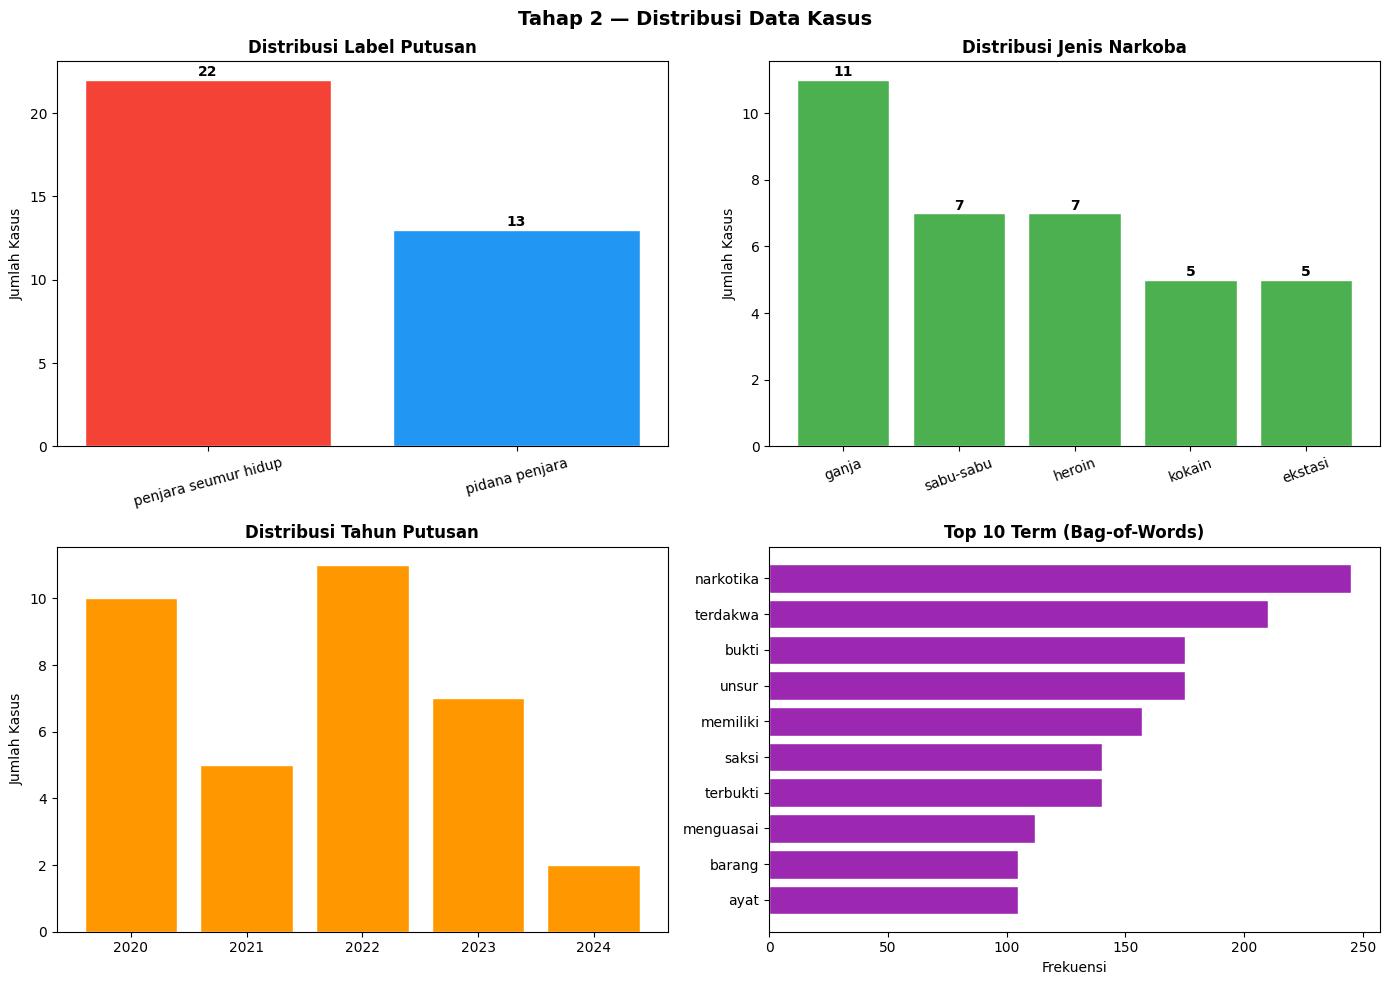

Grafik tersimpan → data/eval/tahap2_distribusi.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Tahap 2 — Distribusi Data Kasus', fontsize=14, fontweight='bold')

# 1. Label Putusan
lbl_counts = df['label_putusan'].value_counts()
axes[0,0].bar(lbl_counts.index, lbl_counts.values,
              color=['#F44336','#2196F3'], edgecolor='white')
axes[0,0].set_title('Distribusi Label Putusan', fontweight='bold')
axes[0,0].set_ylabel('Jumlah Kasus')
axes[0,0].tick_params(axis='x', rotation=15)
for i, v in enumerate(lbl_counts.values):
    axes[0,0].text(i, v+0.2, str(v), ha='center', fontweight='bold')

# 2. Jenis Narkoba
nark_counts = df['jenis_narkoba'].value_counts()
axes[0,1].bar(nark_counts.index, nark_counts.values,
              color='#4CAF50', edgecolor='white')
axes[0,1].set_title('Distribusi Jenis Narkoba', fontweight='bold')
axes[0,1].set_ylabel('Jumlah Kasus')
axes[0,1].tick_params(axis='x', rotation=20)
for i, v in enumerate(nark_counts.values):
    axes[0,1].text(i, v+0.1, str(v), ha='center', fontweight='bold')

# 3. Distribusi Tahun
df['tahun'] = df['tanggal'].str[:4]
tahun_counts = df['tahun'].value_counts().sort_index()
axes[1,0].bar(tahun_counts.index, tahun_counts.values,
              color='#FF9800', edgecolor='white')
axes[1,0].set_title('Distribusi Tahun Putusan', fontweight='bold')
axes[1,0].set_ylabel('Jumlah Kasus')

# 4. Top terms
top10 = top_terms.head(10)
axes[1,1].barh(top10.index[::-1], top10.values[::-1],
               color='#9C27B0', edgecolor='white')
axes[1,1].set_title('Top 10 Term (Bag-of-Words)', fontweight='bold')
axes[1,1].set_xlabel('Frekuensi')

plt.tight_layout()
plt.savefig('data/eval/tahap2_distribusi.png', dpi=120, bbox_inches='tight')
plt.show()
print('Grafik tersimpan → data/eval/tahap2_distribusi.png')

## 2.6 Preview Struktur CSV

Contoh kolom file `cases.csv`:

| case_id | no_perkara | tanggal | terdakwa | pasal | jenis_narkoba | amar_putusan | label_putusan | word_count |
|---------|-----------|---------|----------|-------|---------------|--------------|---------------|------------|
| 1 | 101/Pid.Sus/... | 2023-08-02 | Ahmad Fauzi | 114 ayat (2)... | sabu-sabu | penjara 15 tahun... | pidana penjara | 521 |

In [7]:
display_cols = ['case_id','no_perkara','tanggal','terdakwa','pasal',
                'jenis_narkoba','label_putusan','word_count']
df[display_cols].head(10)

,case_id,no_perkara,tanggal,terdakwa,pasal,jenis_narkoba,label_putusan,word_count
0,1,101/Pid.Sus/2023/PN.Bdg,2023-08-02,Ahmad Fauzi,114 ayat (2) UU No.35 Tahun 2009 tentang Narko...,sabu-sabu,pidana penjara,521
1,2,102/Pid.Sus/2022/PN.Mdn,2022-05-15,Budi Santoso,112 ayat (1) UU No.35 Tahun 2009 tentang Narko...,ganja,pidana penjara,517
2,3,103/Pid.Sus/2020/PN.Mdn,2020-06-12,Cipto Haryono,112 ayat (1) UU No.35 Tahun 2009 tentang Narko...,heroin,penjara seumur hidup,501
3,4,104/Pid.Sus/2022/PN.Mks,2022-04-01,Dedi Kurniawan,132 ayat (1) UU No.35 Tahun 2009 tentang Narko...,ganja,pidana penjara,518
4,5,105/Pid.Sus/2022/PN.Sby,2022-05-14,Eko Prasetyo,111 ayat (1) UU No.35 Tahun 2009 tentang Narko...,kokain,pidana penjara,504
5,6,106/Pid.Sus/2023/PN.Mdn,2023-01-09,Fahri Maulana,112 ayat (1) UU No.35 Tahun 2009 tentang Narko...,kokain,penjara seumur hidup,508
6,7,107/Pid.Sus/2023/PN.Mdn,2023-10-07,Gunawan Hidayat,112 ayat (2) UU No.35 Tahun 2009 tentang Narko...,ganja,penjara seumur hidup,518
7,8,108/Pid.Sus/2022/PN.Mks,2022-08-26,Hendra Wijaya,114 ayat (2) UU No.35 Tahun 2009 tentang Narko...,heroin,penjara seumur hidup,510
8,9,109/Pid.Sus/2024/PN.Jkt.Sel,2024-11-25,Irwan Saputra,114 ayat (1) UU No.35 Tahun 2009 tentang Narko...,sabu-sabu,penjara seumur hidup,525
9,10,110/Pid.Sus/2021/PN.Bdg,2021-03-21,Joko Susilo,114 ayat (1) UU No.35 Tahun 2009 tentang Narko...,sabu-sabu,penjara seumur hidup,518


## 2.7 Output Tahap 2

| Output | Lokasi |
|--------|--------|
| Dataset terstruktur | `data/processed/cases.csv` |
| Dataset JSON | `data/processed/cases.json` |

✅ **Tahap 2 Selesai** — Lanjut ke `Tahap3_Case_Retrieval.ipynb`